# India EV Adoption: Exploratory Analysis

Electric two-wheeler (E2W) registrations from Vahan, loaded into PostgreSQL (`india_ev`).
Periods are Indian financial years (April-March). Data runs from January 2023 to August 2026.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from db import get_engine

engine = get_engine()
IMAGES = Path.cwd().parent / "images"

# reference palette: categorical slots in fixed order, one-hue blue ramp for magnitude
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
OTHER = "#b4b2a9"
BLUE = "#2a78d6"
BLUE_LIGHT = "#9ec5f4"
TEXT, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID,
    "axes.labelcolor": MUTED,
    "axes.titlecolor": TEXT,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "legend.frameon": False,
})


def save(fig, name):
    fig.savefig(IMAGES / name, bbox_inches="tight", dpi=150)

## 1. National trend

In [2]:
national = pd.read_sql("""
    SELECT d.month_start,
           SUM(f.registrations) FILTER (WHERE fu.is_electric) AS e2w,
           SUM(f.registrations)                               AS all_2w
    FROM fact_registrations f
    JOIN dim_date d  ON d.date_key = f.date_key
    JOIN dim_fuel fu ON fu.fuel_key = f.fuel_key
    GROUP BY d.month_start
    ORDER BY d.month_start
""", engine, parse_dates=["month_start"])
national["rolling_3m"] = national["e2w"].rolling(3).mean()
national["penetration_pct"] = 100 * national["e2w"] / national["all_2w"]
national.tail()

,month_start,e2w,all_2w,rolling_3m,penetration_pct
39,2026-04-01,157885,1991835,158634.666667,7.926610
40,2026-05-01,172825,1862888,176765.333333,9.277262
41,2026-06-01,195166,1843708,175292.000000,10.585516
42,2026-07-01,205801,1831363,191264.000000,11.237586
43,2026-08-01,184579,1725992,195182.000000,10.694082


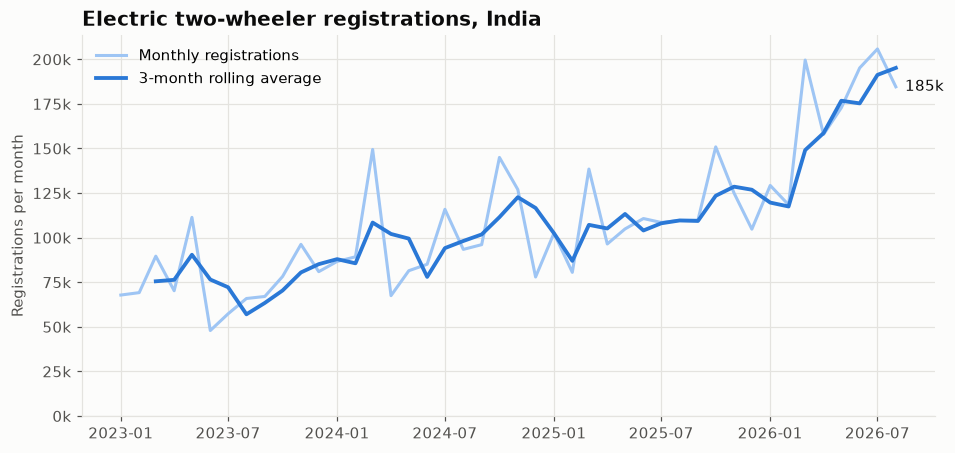

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(national["month_start"], national["e2w"], color=BLUE_LIGHT, linewidth=2, label="Monthly registrations")
ax.plot(national["month_start"], national["rolling_3m"], color=BLUE, linewidth=2.5, label="3-month rolling average")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
ax.set_ylim(bottom=0)
ax.set_title("Electric two-wheeler registrations, India")
ax.set_ylabel("Registrations per month")
ax.legend(loc="upper left")
last = national.iloc[-1]
ax.annotate(f"{last['e2w'] / 1000:.0f}k", (last["month_start"], last["e2w"]),
            xytext=(6, 0), textcoords="offset points", color=TEXT, va="center")
save(fig, "01_national_trend.png")
plt.show()

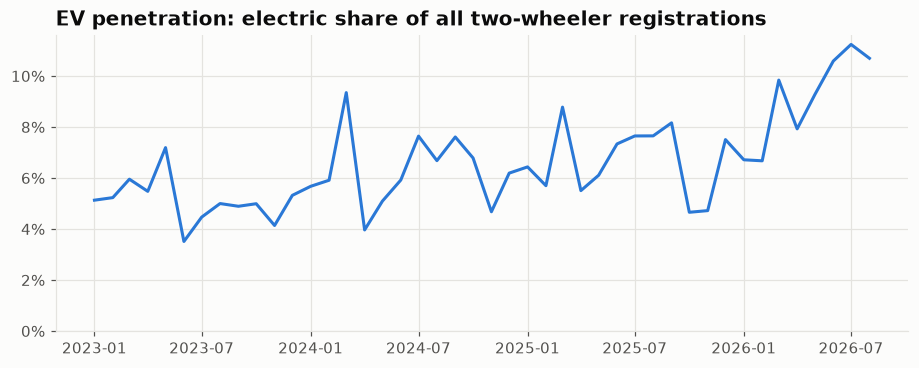

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(national["month_start"], national["penetration_pct"], color=BLUE, linewidth=2)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(bottom=0)
ax.set_title("EV penetration: electric share of all two-wheeler registrations")
save(fig, "02_national_penetration.png")
plt.show()

<!-- my observation here -->

## 2. Penetration by state (latest complete FY)

In [5]:
latest_fy = pd.read_sql(
    "SELECT MAX(fy) AS fy FROM (SELECT fy FROM dim_date GROUP BY fy HAVING COUNT(*) = 12) x", engine
)["fy"].iloc[0]

by_state = pd.read_sql(f"""
    SELECT s.state_name,
           SUM(f.registrations) FILTER (WHERE fu.is_electric) AS e2w,
           SUM(f.registrations)                               AS all_2w
    FROM fact_registrations f
    JOIN dim_date d  ON d.date_key = f.date_key
    JOIN dim_state s ON s.state_key = f.state_key
    JOIN dim_fuel fu ON fu.fuel_key = f.fuel_key
    WHERE d.fy = '{latest_fy}'
    GROUP BY s.state_name
""", engine)
by_state["penetration_pct"] = 100 * by_state["e2w"] / by_state["all_2w"]
national_pen = 100 * by_state["e2w"].sum() / by_state["all_2w"].sum()
# states with fewer than 1,000 E2W a year give unstable percentages
plot_states = by_state[by_state["e2w"] >= 1000].sort_values("penetration_pct")
print(latest_fy, f"national penetration {national_pen:.2f}%")

FY2025-26 national penetration 6.62%


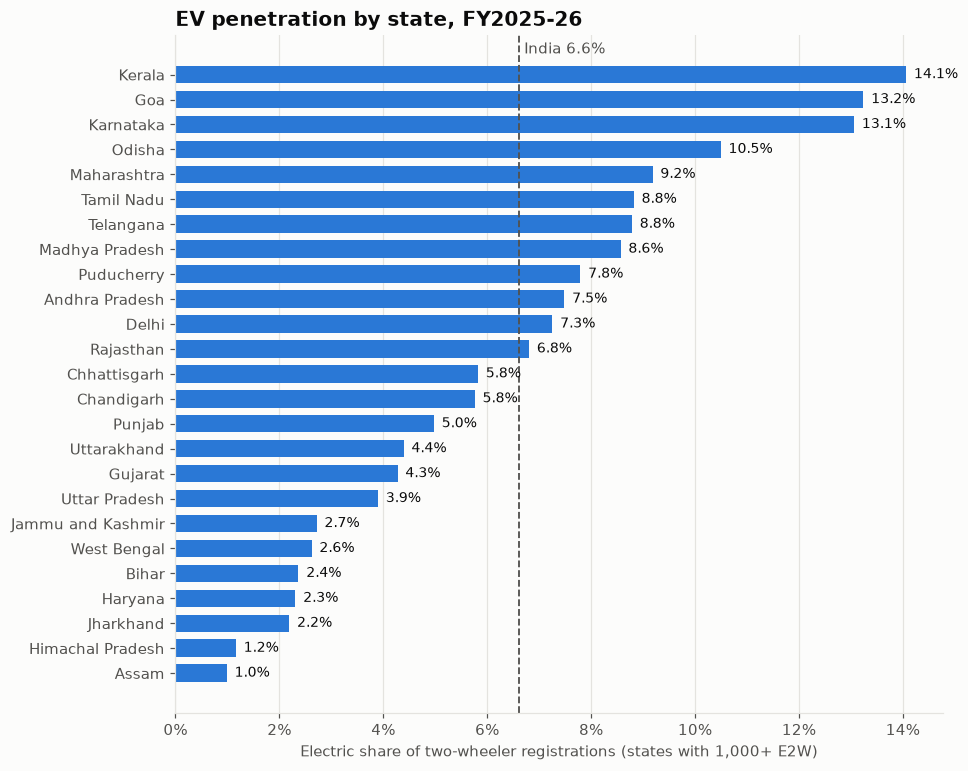

In [6]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(plot_states["state_name"], plot_states["penetration_pct"], color=BLUE, height=0.7)
ax.axvline(national_pen, color=MUTED, linewidth=1.2, linestyle="--")
ax.text(national_pen, len(plot_states) - 0.3, f" India {national_pen:.1f}%", color=MUTED, va="bottom")
for y, v in enumerate(plot_states["penetration_pct"]):
    ax.text(v + 0.15, y, f"{v:.1f}%", va="center", color=TEXT, fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.grid(axis="y", visible=False)
ax.set_title(f"EV penetration by state, {latest_fy}")
ax.set_xlabel("Electric share of two-wheeler registrations (states with 1,000+ E2W)")
save(fig, "03_state_penetration.png")
plt.show()

<!-- my observation here -->

## 3. Maker share over time (top 6 + Others)

In [7]:
makers = pd.read_sql("""
    SELECT d.fy, d.fy_quarter, MIN(d.month_start) AS quarter_start, m.maker_name,
           SUM(f.registrations) AS e2w
    FROM fact_maker_registrations f
    JOIN dim_date d  ON d.date_key = f.date_key
    JOIN dim_maker m ON m.maker_key = f.maker_key
    GROUP BY d.fy, d.fy_quarter, m.maker_name
""", engine)
quarters = makers.groupby(["fy", "fy_quarter"])["quarter_start"].min().reset_index()
top6 = makers.groupby("maker_name")["e2w"].sum().nlargest(6).index.tolist()
makers["group"] = makers["maker_name"].where(makers["maker_name"].isin(top6), "Others")
share = makers.pivot_table(index=["fy", "fy_quarter"], columns="group", values="e2w", aggfunc="sum").fillna(0)
share = share.div(share.sum(axis=1), axis=0) * 100
share = share[top6 + ["Others"]]
share.index = [f"{fy[2:]} {q}" for fy, q in share.index]
share.round(1).tail()

group,TVS Motor,Ola Electric,Bajaj Auto,Ather Energy,Hero MotoCorp (Vida),Ampere (Greaves Electric),Others
2025-26 Q2,22.3,15.8,16.2,17.4,11.5,4.0,12.8
2025-26 Q3,23.7,9.1,20.8,18.7,10.7,4.9,12.1
2025-26 Q4,27.1,5.0,22.5,18.3,11.0,4.1,12.0
2026-27 Q1,24.9,8.4,22.4,17.0,10.9,4.9,11.7
2026-27 Q2,26.9,7.2,22.3,15.3,10.8,4.8,12.6


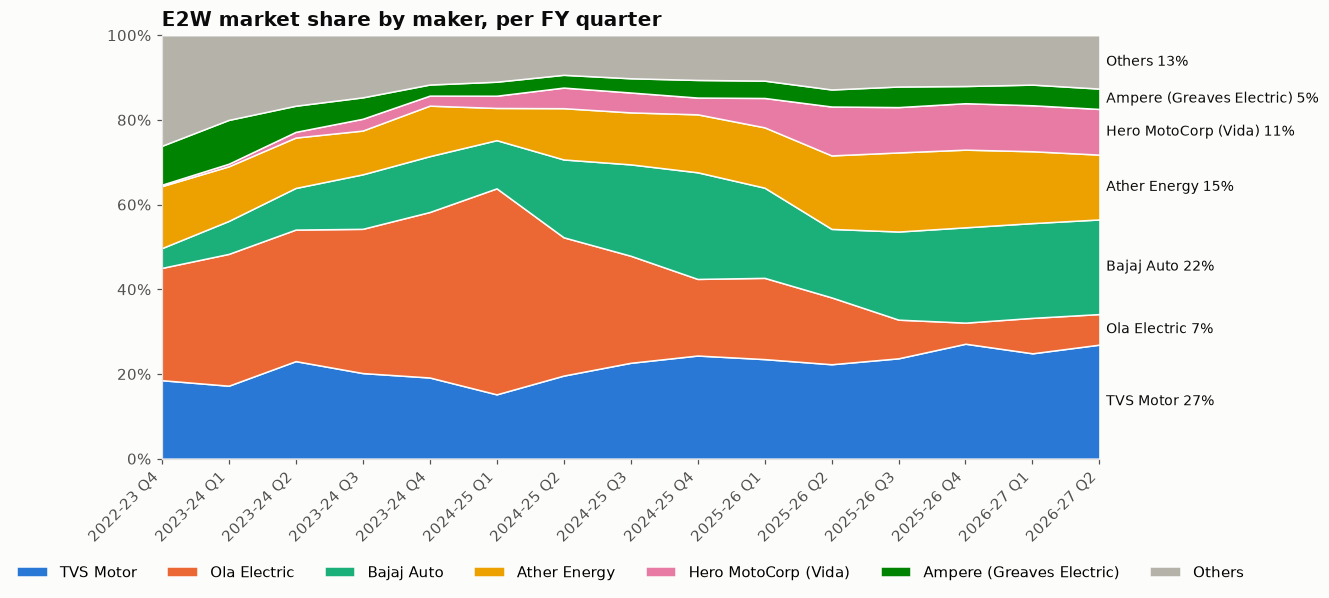

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(share))
ax.stackplot(x, share.T.values, colors=SERIES + [OTHER], labels=share.columns,
             edgecolor="#fcfcfb", linewidth=1)
for i, name in enumerate(share.columns):
    mid = share.iloc[-1, :i].sum() + share.iloc[-1, i] / 2
    if share.iloc[-1, i] >= 3:
        ax.text(len(share) - 0.9, mid, f"{name} {share.iloc[-1, i]:.0f}%", va="center", color=TEXT, fontsize=9)
ax.set_xticks(list(x), share.index, rotation=45, ha="right")
ax.set_xlim(0, len(share) - 1)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.grid(False)
ax.set_title("E2W market share by maker, per FY quarter")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=7)
save(fig, "04_maker_share.png")
plt.show()

<!-- my observation here -->

## 4. State size vs growth (2x2)

In [9]:
prev_fy = f"FY{int(latest_fy[2:6]) - 1}-{latest_fy[4:6]}"
growth = pd.read_sql(f"""
    SELECT s.state_name,
           SUM(f.registrations) FILTER (WHERE d.fy = '{latest_fy}') AS e2w,
           SUM(f.registrations) FILTER (WHERE d.fy = '{prev_fy}')   AS prev_e2w
    FROM fact_registrations f
    JOIN dim_date d  ON d.date_key = f.date_key
    JOIN dim_state s ON s.state_key = f.state_key
    JOIN dim_fuel fu ON fu.fuel_key = f.fuel_key
    WHERE fu.is_electric
    GROUP BY s.state_name
""", engine)
growth = growth[growth["prev_e2w"] >= 1000].copy()
growth["yoy_pct"] = 100 * (growth["e2w"] - growth["prev_e2w"]) / growth["prev_e2w"]
med_size, med_growth = growth["e2w"].median(), growth["yoy_pct"].median()
print(prev_fy, "->", latest_fy, f"median size {med_size:,.0f}, median growth {med_growth:.1f}%")

FY2024-25 -> FY2025-26 median size 33,106, median growth 16.7%


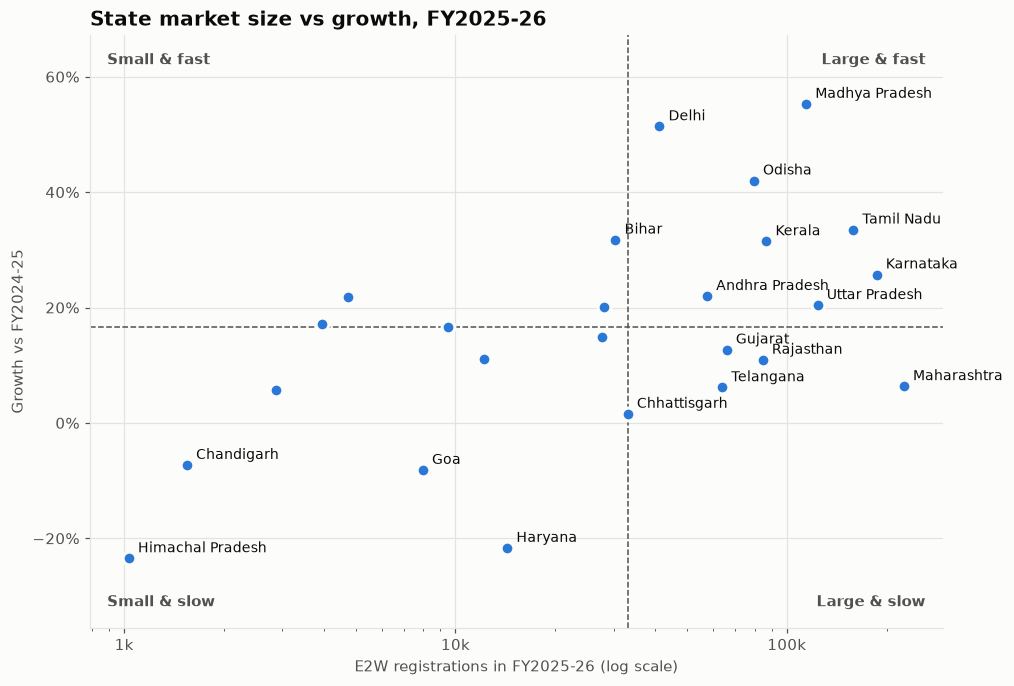

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(growth["e2w"], growth["yoy_pct"], s=70, color=BLUE, edgecolor="#fcfcfb", linewidth=2, zorder=3)
ax.axvline(med_size, color=MUTED, linewidth=1, linestyle="--")
ax.axhline(med_growth, color=MUTED, linewidth=1, linestyle="--")
ax.set_xscale("log")
ax.set_ylim(growth["yoy_pct"].min() - 12, growth["yoy_pct"].max() + 12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1000:.0f}k" if v >= 1000 else f"{v:.0f}"))
labelled = growth[(growth["e2w"] >= med_size) | (growth["yoy_pct"] >= 30) | (growth["yoy_pct"] < 0)]
for _, r in labelled.iterrows():
    ax.annotate(r["state_name"], (r["e2w"], r["yoy_pct"]), xytext=(6, 4), textcoords="offset points",
                fontsize=9, color=TEXT)
for text, xy, ha in [("Large & fast", (0.98, 0.97), "right"), ("Small & fast", (0.02, 0.97), "left"),
                     ("Large & slow", (0.98, 0.03), "right"), ("Small & slow", (0.02, 0.03), "left")]:
    ax.text(*xy, text, transform=ax.transAxes, ha=ha, va="top" if xy[1] > 0.5 else "bottom",
            color=MUTED, fontsize=10, fontweight="bold")
ax.set_title(f"State market size vs growth, {latest_fy}")
ax.set_xlabel(f"E2W registrations in {latest_fy} (log scale)")
ax.set_ylabel(f"Growth vs {prev_fy}")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
save(fig, "05_state_2x2.png")
plt.show()

<!-- my observation here -->

## 5. State x month heatmap (top 15 states)

In [11]:
heat = pd.read_sql("""
    SELECT s.state_name, d.month_start, SUM(f.registrations) AS e2w
    FROM fact_registrations f
    JOIN dim_date d  ON d.date_key = f.date_key
    JOIN dim_state s ON s.state_key = f.state_key
    JOIN dim_fuel fu ON fu.fuel_key = f.fuel_key
    WHERE fu.is_electric
    GROUP BY s.state_name, d.month_start
""", engine, parse_dates=["month_start"])
top15 = heat.groupby("state_name")["e2w"].sum().nlargest(15).index
grid = heat[heat["state_name"].isin(top15)].pivot(index="state_name", columns="month_start", values="e2w")
grid = grid.loc[top15]
grid.columns = [c.strftime("%b %y") for c in grid.columns]

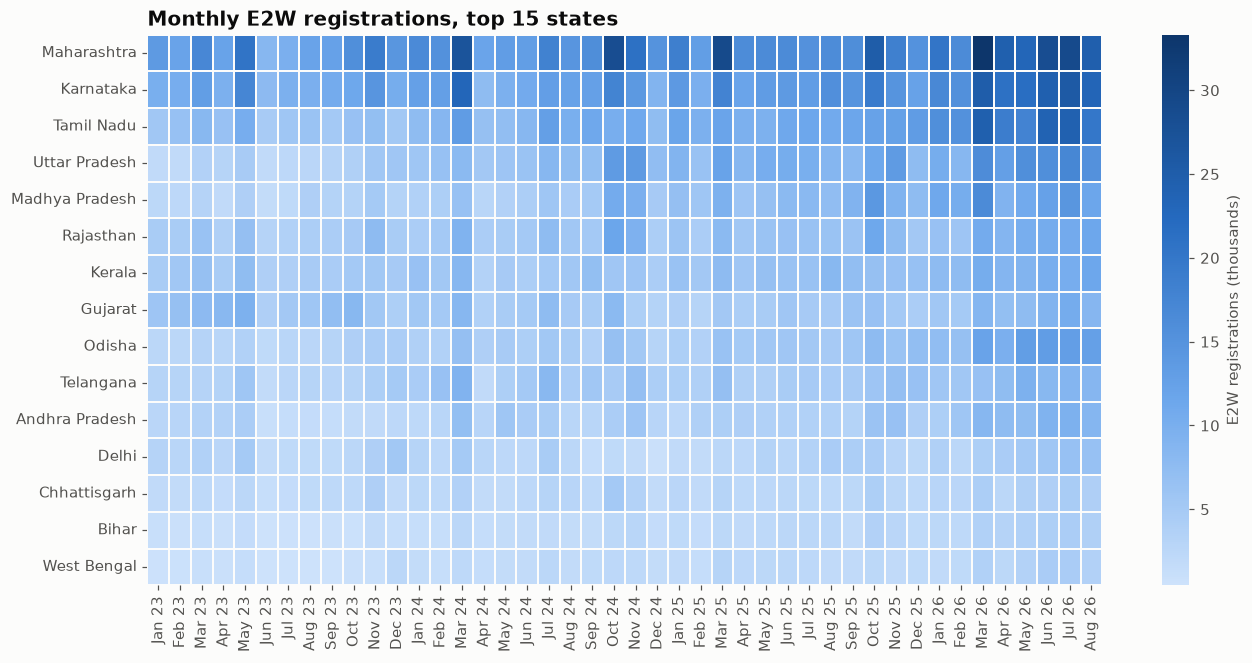

In [12]:
blues = sns.blend_palette(["#cde2fb", "#6da7ec", "#256abf", "#0d366b"], as_cmap=True)
fig, ax = plt.subplots(figsize=(14, 6.5))
sns.heatmap(grid / 1000, cmap=blues, linewidths=1, linecolor="#fcfcfb",
            cbar_kws={"label": "E2W registrations (thousands)"}, ax=ax)
ax.grid(False)
ax.set_title("Monthly E2W registrations, top 15 states")
ax.set_xlabel("")
ax.set_ylabel("")
save(fig, "06_state_month_heatmap.png")
plt.show()

<!-- my observation here -->